# Gene-driven Perturbation (GNP) Knockout Simulation
This tutorial demonstrates how to use the GNP (Gene Network Perturbation) module to perform a silico knockout on mouse Stereo-seq data.

1. Dataset Overview
We utilize high-resolution spatial transcriptomics data from the Ma2024 dataset:

Study: Spatial transcriptomic landscape unveils immunoglobulin-associated senescence as a hallmark of aging (Ma, Shuai et al., Cell, 2024).

Biological Context: Analyzing the spatial distribution of senescence markers in the aging mouse brain.

In [1]:
import os
import torch
import numpy as np
import pandas as pd
import scanpy as sc
import gseapy as gp
import anndata as ad
import seaborn as sns
from typing import Optional
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import sys
sys.path.append("/inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/Brainbeacon_v2/BrainBeacon/")
from brainbeacon.pipeline.cell_embedding import run_bbcellformer_pipeline
from brainbeacon.pipeline.perturbation import apply_gene_perturbation, inject_cells_into_niche, plot_cosine_to_centroids_with_perturb
from brainbeacon.pipeline.perturbation import analyze_embedding_similarity_change, plot_cosine_to_centroids_with_perturb
from brainbeacon.pipeline.perturbation import analyze_embedding_similarity_change_similarity_niche
from brainbeacon.utils import set_seed
import brainbeacon.configs.config as cfg
from brainbeacon.configs.config_train import config_train as cfg_train
from brainbeacon.utils import compute_density_token, compute_deviation_bin_rapid_v2
from brainbeacon.utils import convert_spatial_to_um, platform_radius_map
import logging
logging.basicConfig(
    level=logging.INFO,  # 或 level=logging.DEBUG
    format='%(asctime)s %(levelname)s %(message)s'
)

import warnings
plt.rcParams["pdf.fonttype"] = 42
warnings.filterwarnings("ignore")
set_seed(42)

/inspire/ssd/tenant_predefaa-9a1b-4522-bb10-8850f313be13/global_user/7936-yangyiwen/conda/miniconda/envs/bb_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Device setup

In [2]:
# Set GPU 
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"Using GPU: {torch.cuda.get_device_name(torch.cuda.current_device())}")

# Define base paths and dataset info
out_fig_dir = "/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/output/virtual_perturbation/fig4_subfig"
os.makedirs(out_fig_dir, exist_ok=True)

Using device: cuda
Using GPU: NVIDIA H800


## Paths and dataset config
**Example dataset ()**

Path to the processed AnnData object used in this tutorial.
The processed file (adata_outer_ensembl.h5ad) can be downloaded directly from:
https://drive.google.com/file/d/1-z8J8xiRN0qD0preVQr8cAHKQXuScBp2/view?usp=drive_link
Alternatively, the original raw Stereo-seq data can be obtained from the CNGBdb STOmics portal:
https://db.cngb.org/stomics/datasets/STDS0000247/data

In [3]:
# =============================================================================
# Dataset and Basic Setup
# =============================================================================
dataset_name = "ma2024aging_cell2niche_niche_inner"
specie = "mouse"  # NOTE: keep original variable name for compatibility
assay = "stereo"

# =============================================================================
# Prior Knowledge / Paths
# =============================================================================
# Base directories
BASE_DIR = Path("/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/")

# Sync into cfg (assumes cfg / cfg_train already exist in your notebook/runtime)
cfg.DEFAULT_PATHS["BASE_DIR"] = str(BASE_DIR)
cfg.DEFAULT_PATHS["PRETRAIN_DIR"] = "/inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/Brainbeacon/bb_PriorKnowledge/"
cfg.DEFAULT_PATHS["PRIOR_DIR"] = cfg.DEFAULT_PATHS["PRETRAIN_DIR"]
cfg.DEFAULT_PATHS["GENE_DICT_PATH"] = (
    "/inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/Brainbeacon/bb_PriorKnowledge/model_h5ad_1211.h5ad"
)

# Users may start from the raw data and follow their own preprocessing pipeline if desired.
adata_path = BASE_DIR / "data" / "adata_outer_ensembl.h5ad"  # adata_outer_ensembl / adata_inner_ensembl
gene_dict_path = Path(cfg.DEFAULT_PATHS["GENE_DICT_PATH"])
gene_mean_path = Path(
    "/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/bb_PriorKnowledge/stereo-seq_gene_nonzero_means_metacell_2.npy"
)

# ESM embedding path
cfg_train["esm_embedding_path"] = (
    "/inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/Brainbeacon/bb_PriorKnowledge/esm2_embeddings_d5120.pt"
)

# Basic sanity checks (fail fast)
assert adata_path.exists(), f"adata_path not found: {adata_path}"
assert gene_dict_path.exists(), f"gene_dict_path not found: {gene_dict_path}"
assert gene_mean_path.exists(), f"gene_mean_path not found: {gene_mean_path}"
assert Path(cfg_train["esm_embedding_path"]).exists(), f"esm_embedding_path not found: {cfg_train['esm_embedding_path']}"

# =============================================================================
# Pretrained Checkpoints
# =============================================================================
pretrain_dir = BASE_DIR / "pretrained"

bb_ckpt_name = "epoch_0_setp_800000.pt"
cellformer_ckpt_name = "cellformer_epoch99.pt"  # trained on all ma2024aging data
# cellformer_ckpt_name = "cellformer.ckpt"      # CellPLM original checkpoint

bb_ckpt_path = Path("/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/bb_PriorKnowledge/epoch_0_step_800000.pt")
cellplm_ckpt_path = Path("/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/bb_PriorKnowledge/cellformer_epoch99.pt")

assert bb_ckpt_path.exists(), f"bb_ckpt_path not found: {bb_ckpt_path}"
assert cellplm_ckpt_path.exists(), f"cellplm_ckpt_path not found: {cellplm_ckpt_path}"

# =============================================================================
# Output Naming
# =============================================================================
cd_weight = 0.02
use_hvg = True
n_hvg = 5000

bb_ckpt_tag = bb_ckpt_name.replace(".pt", "").replace(".ckpt", "")
if use_hvg:
    method_name = f"bbcellformer_{bb_ckpt_tag}_hvg{n_hvg}_cd{cd_weight}"
else:
    method_name = f"bbcellformer_{bb_ckpt_tag}_cd{cd_weight}"

output_dir = BASE_DIR / "downstream_tasks" / "virtual_perturbation" / "outputs" / dataset_name / method_name
output_dir.mkdir(parents=True, exist_ok=True)

# =============================================================================
# Load Data and (Optionally) Select Slices
# =============================================================================
full_adata = sc.read_h5ad(str(adata_path))

selected_slices = ["Hippocampus_Y_2_1", "Hippocampus_O_2_1"]

# NOTE: Uncomment if you want to restrict to selected slices
# adata = full_adata[full_adata.obs["slice"].isin(selected_slices)].copy()
adata = full_adata.copy()

# =============================================================================
# Derive Labels
# =============================================================================
def infer_cell_label(slice_name: str) -> Optional[str]:
    """Infer 'Young' / 'Old' from slice naming convention."""
    if slice_name.startswith("Hippocampus_Y"):
        return "Young"
    if slice_name.startswith("Hippocampus_O"):
        return "Old"
    return None  # Unknown slice pattern

# Apply label + batch
adata.obs["cell_label"] = adata.obs["slice"].astype(str).map(infer_cell_label)
adata.obs["batch"] = adata.obs["slice"]

# Enforce categorical type (keeps only 'Young' and 'Old' as known categories)
adata.obs["cell_label"] = pd.Categorical(adata.obs["cell_label"], categories=["Young", "Old"])

In [4]:
DEG_path = "/inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/bb_PriorKnowledge/1-s2.0-S0092867424012017-mmc2.xlsx" 
#download from supplementary materials of Ma et al., Cell, 2024
DEG_df = pd.read_excel(DEG_path, sheet_name="Hippocampus", skiprows=1)
n_unique_genes = DEG_df["Gene"].str.upper().nunique()
print("Unique gene count:", n_unique_genes)

Unique gene count: 2628


## Set ROI
Next, we select regions of interest (ROIs) to further investigate
how the perturbation reshapes local cellular niches after gene perturbation.
These ROIs enable a focused analysis of spatial and niche-level changes
induced by the perturbation.

AnnData object with n_obs × n_vars = 481 × 20318
    obs: 'x', 'y', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'clusters', 'cell_label', 'slice', 'species', 'age_group', 'batch'
    var: 'gene_symbol', 'ensembl', 'human_symbol', 'human_ensembl'
    obsm: 'X_pca', 'X_umap', 'spatial'
    layers: 'lognorm', 'raw_count'


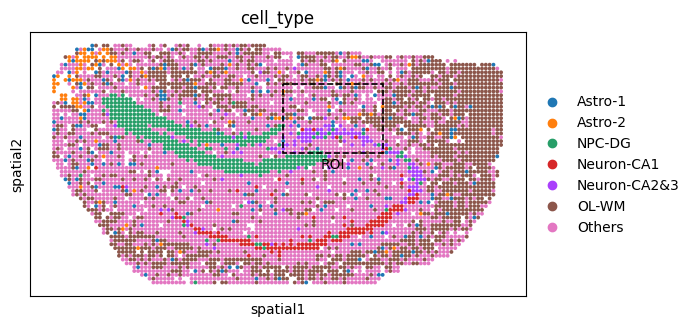

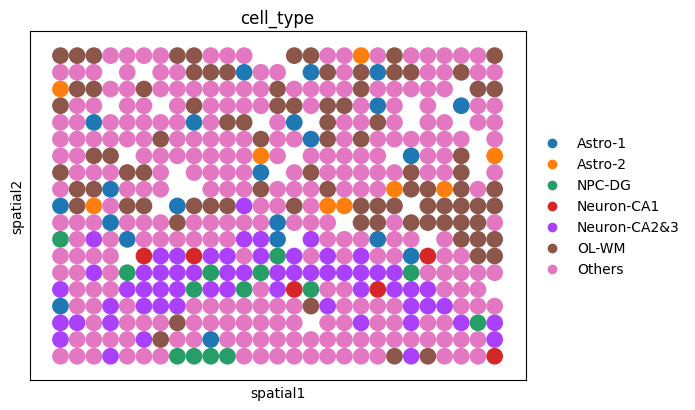

In [5]:
ol_cells = adata[adata.obs["slice"] == "Hippocampus_O_2_1"].copy()
ol_roi = ol_cells[
    (ol_cells.obsm["spatial"][:, 0] > 60) &    
    (ol_cells.obsm["spatial"][:, 1] > 10) &    
    (ol_cells.obsm["spatial"][:, 0] < 88) &      
    (ol_cells.obsm["spatial"][:, 1] < 30)
].copy()
print(ol_roi)
ol_cells.obs["cell_type"] = ol_cells.obs["cell_type"].astype("category")
categories = ol_cells.obs["cell_type"].cat.categories
ol_roi.obs["cell_type"] = pd.Categorical(
    ol_roi.obs["cell_type"], categories=categories, ordered=True
)

ol_cells.uns["cell_type_colors"] = ol_cells.uns.get(
    "cell_type_colors", sc.pl.palettes.default_20[:len(categories)]
)
ol_roi.uns["cell_type_colors"] = ol_cells.uns["cell_type_colors"]

roi_coords = ol_roi.obsm["spatial"]
xmin, xmax = roi_coords[:, 0].min(), roi_coords[:, 0].max()
ymin, ymax = roi_coords[:, 1].min(), roi_coords[:, 1].max()
xcenter, ycenter = (xmin + xmax) / 2, (ymin + ymax) / 2
os.makedirs(out_fig_dir, exist_ok=True)

fig_ol = sc.pl.spatial(
    ol_cells, color="cell_type", spot_size=1, show=False, return_fig=True
)
ax_ol = fig_ol.axes[0]
rect = Rectangle(
    (xmin, ymin), xmax - xmin, ymax - ymin,
    linewidth=1.2, edgecolor='black', facecolor='none', linestyle='--'
)
ax_ol.add_patch(rect)

ax_ol.text(
    xcenter, ymax + 5, "ROI",
    color='black', fontsize=10, ha='center', va='bottom'
)
fig_roi = sc.pl.spatial(
    ol_roi, color="cell_type", spot_size=1, show=False, return_fig=True
)


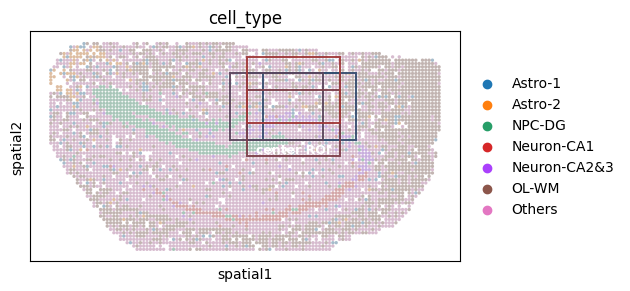

In [6]:
# This snippet visualizes ROI “jittering” (window shifting) by drawing multiple shifted ROI boxes
# on the same spatial plot, illustrating how small window movements can improve robustness.

fig_ol = sc.pl.spatial(
    ol_cells,
    color="cell_type",
    spot_size=1,
    show=False,
    return_fig=True,
)
ax_ol = fig_ol.axes[0]

# Make all cell-type colors more muted (blend with gray) for better ROI contrast
gray = np.array([0.5, 0.5, 0.5, 1.0])
for c in ax_ol.collections:
    facecolors = c.get_facecolor()
    c.set_facecolor(0.5 * facecolors + 0.5 * gray)
    c.set_alpha(0.5)

# Base ROI coordinates and a set of small shifts (jitter)
ol_base_x, ol_base_y = (60, 88), (10, 30)
shifts = [
    (0, 0),
    (5, 0),
    (-5, 0),
    (0, 5),
    (0, -5),
]

# Color gradient for shifted ROI boxes
start_color = "#145583"
end_color = "#A13939"
cmap = LinearSegmentedColormap.from_list("blue_red", [start_color, end_color])
colors = [cmap(i / (len(shifts) - 1)) for i in range(len(shifts))]

# Draw ROI boxes with different shifts
for i, (dx, dy) in enumerate(shifts):
    xmin, xmax = ol_base_x[0] + dx, ol_base_x[1] + dx
    ymin, ymax = ol_base_y[0] + dy, ol_base_y[1] + dy

    ax_ol.add_patch(
        Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            linewidth=1.4,
            edgecolor=colors[i],
            facecolor="none",
            linestyle="-",
            alpha=0.95,
        )
    )

# Annotate the center ROI
ax_ol.text(
    np.mean(ol_base_x),
    ol_base_y[1] + 5,
    "center ROI",
    color="white",
    fontsize=9,
    weight="bold",
    ha="center",
    va="bottom",
)

plt.tight_layout()
# plt.savefig(f"{out_fig_dir}/c2n_ol_cells_with_multiple_roi_boxes.pdf", bbox_inches="tight")
plt.show()

x: 1.0 ~ 85.0, y: 1.0 ~ 52.0
ROI cells: 495


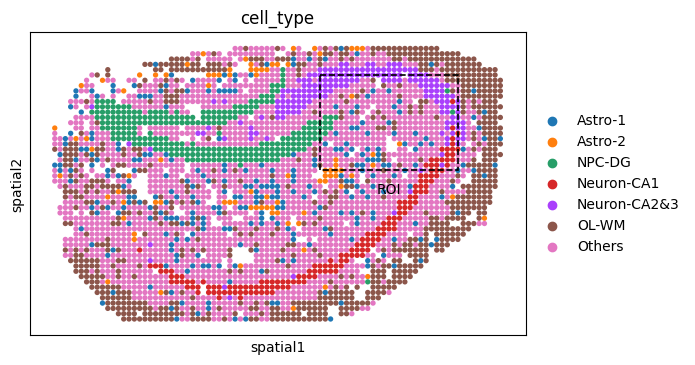

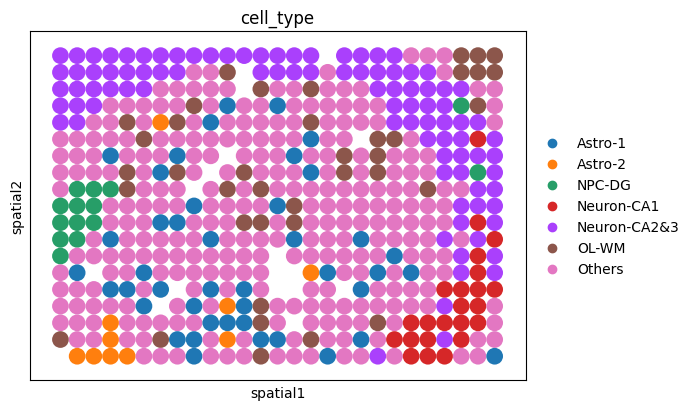

In [7]:
# === Matplotlib settings (ensure editable text in PDF/SVG) ===
warnings.filterwarnings("ignore")
logging.getLogger('matplotlib.font_manager').disabled = True

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype']  = 42
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.family'] = 'sans-serif'

# === Ensure output directory ===
os.makedirs(out_fig_dir, exist_ok=True)

# === Step 1: subset slice ===
adata_Y = adata[adata.obs["slice"] == "Hippocampus_Y_2_1"].copy()

# === Step 2: coordinates ===
x = adata_Y.obsm["spatial"][:, 0]
y = adata_Y.obsm["spatial"][:, 1]
print(f"x: {x.min():.1f} ~ {x.max():.1f}, y: {y.min():.1f} ~ {y.max():.1f}")

# === Step 3: ROI bounds (x in (60, 88), y in (10, 30)) ===
roi_mask = (x > 50) & (x < 78) & (y > 5) & (y < 25)
y_roi = adata_Y[roi_mask].copy()
print(f"ROI cells: {y_roi.n_obs}")

# === Step 4: sync categories & colors ===
adata_Y.obs["cell_type"] = adata_Y.obs["cell_type"].astype("category")
cats = adata_Y.obs["cell_type"].cat.categories
y_roi.obs["cell_type"] = pd.Categorical(y_roi.obs["cell_type"], categories=cats, ordered=True)

adata_Y.uns["cell_type_colors"] = adata_Y.uns.get(
    "cell_type_colors", sc.pl.palettes.default_20[:len(cats)]
)
y_roi.uns["cell_type_colors"] = adata_Y.uns["cell_type_colors"]

# === Step 5a: full view with ROI box ===
fig1 = sc.pl.spatial(adata_Y, color="cell_type", spot_size=1, show=False, return_fig=True)

# Add dashed ROI box
roi_xy = y_roi.obsm["spatial"]
xmin, xmax = roi_xy[:, 0].min(), roi_xy[:, 0].max()
ymin, ymax = roi_xy[:, 1].min(), roi_xy[:, 1].max()
xcenter, ycenter = (xmin + xmax) / 2, (ymin + ymax) / 2

ax = fig1.axes[0]
rect = Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                 linewidth=1.2, edgecolor='black', facecolor='none', linestyle='--')
ax.add_patch(rect)
ax.text(xcenter, ymax + 5, "ROI", color='black', fontsize=10, ha='center', va='bottom')
# === Step 5b: ROI-only ===
fig2 = sc.pl.spatial(y_roi, color="cell_type", spot_size=1, show=False, return_fig=True)

In [8]:
ol_roi.obs["brain_region"] = ol_roi.obs["slice"]
ol_roi.obs["brain_region_main"] = ol_roi.obs["slice"]
ol_roi.obsm["spatial"] = ol_roi.obsm["spatial"].astype(np.float32)
ol_roi = compute_deviation_bin_rapid_v2(ol_roi)
ol_roi = convert_spatial_to_um(ol_roi, "STEREO")
radius = platform_radius_map.get("STEREO_bin", 8)
ol_roi, _ = compute_density_token(ol_roi, radius)

y_roi.obs["brain_region"] = y_roi.obs["slice"]
y_roi.obs["brain_region_main"] = y_roi.obs["slice"]
y_roi.obsm["spatial"] = y_roi.obsm["spatial"].astype(np.float32)
y_roi = compute_deviation_bin_rapid_v2(y_roi)
y_roi = convert_spatial_to_um(y_roi, "STEREO")
radius = platform_radius_map.get("STEREO_bin", 8)
y_roi, _ = compute_density_token(y_roi, radius)

In [9]:
adata_fov_OL = ad.concat([ol_roi, y_roi], join="outer")
adata_fov_OL.var = adata.var.loc[adata_fov_OL.var_names].copy()
output_prefix_ori = "original"
adata_fov_OL.obs["split"] = "train"
os.makedirs(output_dir, exist_ok=True)
ori_input_adata_path = os.path.join(output_dir, f"{output_prefix_ori}_input.h5ad")
adata_fov_OL.write(ori_input_adata_path)
print(f"Saved selected slices to: {ori_input_adata_path}")

... storing 'slice_brain_area' as categorical
... storing 'split' as categorical


Saved selected slices to: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inner/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/original_input.h5ad


In [10]:
print(ol_roi)
print(y_roi)
print(adata)
print(adata_fov_OL)

AnnData object with n_obs × n_vars = 481 × 20318
    obs: 'x', 'y', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'clusters', 'cell_label', 'slice', 'species', 'age_group', 'batch', 'brain_region', 'brain_region_main', 'slice_brain_area', 'density_token'
    var: 'gene_symbol', 'ensembl', 'human_symbol', 'human_ensembl'
    uns: 'cell_type_colors'
    obsm: 'X_pca', 'X_umap', 'spatial', 'deviation_bin', 'neighbor_gene_distribution', 'spatial_um'
    layers: 'lognorm', 'raw_count'
AnnData object with n_obs × n_vars = 495 × 20318
    obs: 'x', 'y', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_i

Unique gene count (global): 2628
Processing OL-WM...
Processing Astro-2...
Processing Astro-1...
Processing NPC-DG...
Processing Neuron-CA2&3...
Processing Neuron-CA1...


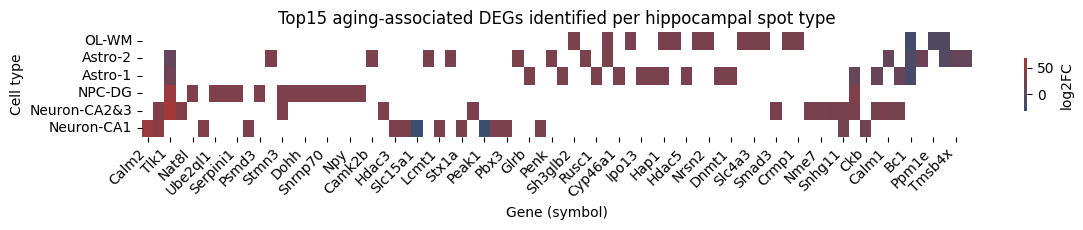

In [11]:
# This snippet visualizes the overlap between a curated DEG list (DEG_df)
# and the aging-associated gene set provided by Ma et al., Cell (2024),
# by computing cell type–specific Old vs Young DEGs and summarizing the top genes as a log2FC heatmap.

unique_genes_global = set(DEG_df["Gene"].unique())
print("Unique gene count (global):", len(unique_genes_global))

adata_no_others = adata_fov_OL[adata_fov_OL.obs["cell_type"] != "Others", :].copy()

adata_no_others.obs["group"] = adata_no_others.obs["slice"].map(
    {
        "Hippocampus_O_2_1": "Old",
        "Hippocampus_Y_2_1": "Young",
    }
)

pval_thr = 0.01

deg_results = {}
all_top_genes = {}

for ct in adata_no_others.obs["cell_type"].unique():
    print(f"Processing {ct}...")

    adata_ct = adata_no_others[adata_no_others.obs["cell_type"] == ct, :].copy()
    if adata_ct.n_obs < 5:
        print(f"  Skip {ct} (too few cells)")
        continue

    sc.tl.rank_genes_groups(
        adata_ct,
        groupby="group",
        reference="Young",
        method="wilcoxon",
    )
    deg_df = sc.get.rank_genes_groups_df(adata_ct, group="Old")

    id_to_symbol = adata_ct.var["gene_symbol"].to_dict()
    deg_df["gene_symbol"] = deg_df["names"].map(id_to_symbol)

    deg_df = deg_df[deg_df["pvals"] < pval_thr].copy()
    if deg_df.empty:
        continue

    deg_df = deg_df[deg_df["gene_symbol"].isin(unique_genes_global)]
    if deg_df.empty:
        continue

    deg_df = deg_df.sort_values(by="logfoldchanges", key=abs, ascending=False)

    # Top 15 genes per cell type
    top_genes = deg_df.head(15)
    top_symbols = top_genes["gene_symbol"].tolist()

    all_top_genes[ct] = top_symbols
    deg_results[ct] = top_genes.set_index("gene_symbol")["logfoldchanges"]

logfc_mat = pd.DataFrame(deg_results).T

gene_abs_mean = logfc_mat.abs().mean(axis=0)
final_gene_order = gene_abs_mean.sort_values(ascending=False).index.tolist()
logfc_mat = logfc_mat[final_gene_order]

cmap = LinearSegmentedColormap.from_list("custom", ["#145583", "#A13939"])

n_celltypes = logfc_mat.shape[0]
fig_height = max(2, 0.4 * n_celltypes)

plt.figure(figsize=(12, fig_height))
sns.heatmap(
    logfc_mat,
    cmap=cmap,
    center=0,
    annot=False,
    cbar_kws={
        "shrink": 0.5,
        "label": "log2FC",
    },
)
plt.title("Top15 aging-associated DEGs identified per hippocampal spot type")
plt.ylabel("Cell type")
plt.xlabel("Gene (symbol)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
# plt.savefig(f"{out_fig_dir}/Top15 aging-associated DEGs_heatmap.pdf", bbox_inches="tight")
plt.show()

## Run Original Inference
This step constructs the baseline (unperturbed) reference by running inference kon the original data, which serves as the control condition for all subsequent perturbation analyses.

In [12]:
adata_ori = run_bbcellformer_pipeline(
    adata_path=ori_input_adata_path,
    specie=specie,
    assay=assay,
    gene_dict_path=gene_dict_path,
    gene_mean_path=gene_mean_path,
    bb_ckpt_path=bb_ckpt_path,
    cellplm_ckpt_path=cellplm_ckpt_path,
    output_dir=output_dir,
    output_prefix=output_prefix_ori,
    config_train=cfg_train,
    n_hvg=n_hvg,
    cd_weight=cd_weight,
    use_hvg=use_hvg,
    weight_mode="expression",
    use_batch=False,
    use_spatial=True,
    force_tokenize=True,
    do_fit=True,  # recommended to set to True for original reconstruction
    device=device,
    fit_epochs=100,
)
print("Original reconstruction complete. Embeddings and model saved.")
print("adata_ori:", adata_ori)

ori_result_adata_path = os.path.join(output_dir, f"{output_prefix_ori}_result.h5ad")
adata_ori.write(ori_result_adata_path)
print(f"Original result adata saved to: {ori_result_adata_path}")


Forcing re-tokenization: clearing existing .parquet files and token folders...
No existing tokenized files found. Running tokenization...
path to process: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inner/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/original_input.h5ad
before quality control adata shape: (976, 20318)
After HVG (5000) selection: (976, 5000)
Computing cell density...
compute_density_token time:  0.0038423975308736163 min


Processing data batches: 100%|██████████| 1/1 [00:04<00:00,  4.91s/it]


Begin processing: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inner/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/original_bb_token_dir/tokens-0000.parquet
Table shape from parquet = 976
Preprocessing time: 0.12 minutes
Loaded pretrain_model checkpoint: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/bb_PriorKnowledge/epoch_0_step_800000.pt


Processing batches: 100%|██████████| 16/16 [00:25<00:00,  1.62s/it]


obs_names and pred_indices are in the same order.
Embeddings saved to /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inner/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/original_bb_embeddings.npz
Time cost:  0.561520532766978
BB inference complete. Saved to: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inner/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/original_bb_embeddings.npz
[INFO] Using explicitly provided CellFormer checkpoint: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/bb_PriorKnowledge/cellformer_epoch99.pt
********** gene list size: 92076 **********
********** loading skip parameters: set() **********
After filtering, 20316 genes remain.


...

Epoch 98 | Train loss: 6803.6355 | Valid loss: 6843.8608


100%|██████████| 100/100 [01:00<00:00,  1.66it/s]

Epoch 99 | Train loss: 6832.2544 | Valid loss: 6840.0640
After filtering, 20316 genes remain.



... storing 'platform' as categorical
... storing 'valid_split' as categorical


Model saved to /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inner/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/original_cellformer.pt
Embeddings saved to /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inner/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/original_embeddings.npz
Original reconstruction complete. Embeddings and model saved.
adata_ori: AnnData object with n_obs × n_vars = 976 × 20316
    obs: 'x', 'y', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'clusters', 'cell_label', 'slice', 'species', 'age_group', 'batch', 'brain_region'

## Example perturbation (in silico knockout) and pre/post effect evaluation
This module demonstrates an in silico gene knockout workflow on a specific cell population.
Here we use OL-WM cells as an example and knock out Meg3 in the Old mouse hippocampus slice
("Hippocampus_O_2_1") by setting its expression to 0 in the selected cells.

After perturbation, we evaluate how the niche-level representation/distribution changes by
comparing pre- vs post-perturbation metrics, including:
  - Cosine similarity
  - Euclidean distance
  - Wasserstein distance (EMD)
  - Maximum Mean Discrepancy (MMD)

You can adapt this example by changing:
  - gene_list: the gene(s) you want to perturb (e.g., ["Igkc"], ["Apoe"], ...)
  - filter_by: the target slice and/or cell type (e.g., other slices, other cell types)
  - mode: perturbation type such as "knockout" or other supported modes in your function
  - multiplier: optional scaling factor if you use a non-knockout perturbation mode

In [13]:
perturbed_adata_final, perturbed_cells_final = apply_gene_perturbation(
    adata=adata_fov_OL,
    gene_list=["Meg3"],  # Replace with genes of interest, e.g., ["Igkc"] or multiple genes ["GeneA", "GeneB"]
    mode="knockout",  # Perturbation mode; replace with other supported modes if needed
    filter_by={
        "slice": "Hippocampus_O_2_1",  # Replace with a different slice if you want to target another region/sample
        "cell_type": "OL-WM",          # Replace with a different cell type (or other metadata keys) as your target
    },
    multiplier=None,  # Optional; set if using a scaling-based perturbation mode (e.g., suppression/overexpression)
)
print(f"Perturbed {len(perturbed_cells_final)} cells: set expression of target gene(s) to 0.")

# Save perturbed input data
output_prefix_perturb = "ko_old_final"
perturb_input_adata_path = os.path.join(output_dir, f"{output_prefix_perturb}_input.h5ad")
perturbed_adata_final.write(perturb_input_adata_path)
print(f"Perturbed {len(perturbed_cells_final)} cells: set expression of target gene(s) to 0.")

# Save perturbed input data
output_prefix_perturb = "ko_old_final"
perturb_input_adata_path = os.path.join(output_dir, f"{output_prefix_perturb}_input.h5ad")
perturbed_adata_final.write(perturb_input_adata_path)
print(f"Perturbed input adata saved to: {perturb_input_adata_path}")

# ========== Run Perturbation Inference ==========
cellplm_ckpt_path = os.path.join(output_dir, f"{output_prefix_ori}_cellformer.pt")
adata_perturb_final = run_bbcellformer_pipeline(
    adata_path=perturb_input_adata_path,
    specie=specie,
    assay=assay,
    gene_dict_path=gene_dict_path,
    gene_mean_path=gene_mean_path,
    bb_ckpt_path=bb_ckpt_path,
    cellplm_ckpt_path=cellplm_ckpt_path,
    output_dir=output_dir,
    output_prefix=output_prefix_perturb,
    config_train=cfg_train,
    n_hvg=n_hvg,
    cd_weight=cd_weight,
    use_hvg=use_hvg,
    use_batch=False,
    use_spatial=True,
    weight_mode="expression",
    force_tokenize=True,
    do_fit=False,
    fit_epochs=10,
    device=device
)
print("Perturbation reconstruction complete. Embeddings and model saved.")
print("adata_perturb:", adata_perturb_final)

perturb_result_adata_path = os.path.join(output_dir, f"{output_prefix_perturb}_result.h5ad")
adata_perturb_final.write(perturb_result_adata_path)
print(f"Perturbation result adata saved to: {perturb_result_adata_path}")

# ========== Analyze Embedding Similarity Change ==========
target_slice_young = "Hippocampus_Y_2_1"
target_slice_old = "Hippocampus_O_2_1"
target_celltype = "OL-WM"

print("\n>>> Analyzing embedding similarity between old and young cells...")
sim_ko_meg3 = analyze_embedding_similarity_change(
    adata_ori_result=adata_ori,
    adata_perturb_result=adata_perturb_final,
    target_slice_young=target_slice_young,
    target_slice_old=target_slice_old,
    target_celltype=target_celltype,
    embedding_key="X_emb"
)
sim_ko_meg3_niche = analyze_embedding_similarity_change_similarity_niche(
    adata_ori_result=adata_ori,
    adata_perturb_result=adata_perturb_final,
    target_slice_young=target_slice_young,
    target_slice_old=target_slice_old,
    target_celltype=target_celltype,
    embedding_key="X_emb"
)

Perturbed 88 cells: set expression of target gene(s) to 0.
Perturbed 88 cells: set expression of target gene(s) to 0.
Perturbed input adata saved to: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inner/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/ko_old_final_input.h5ad
Forcing re-tokenization: clearing existing .parquet files and token folders...
No existing tokenized files found. Running tokenization...
path to process: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inner/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/ko_old_final_input.h5ad
before quality control adata shape: (976, 20318)
After HVG (5000) selection: (976, 5000)
Computing cell density...
compute_density_token time:  0.003927679856618246 min


Processing data batches: 100%|██████████| 1/1 [00:00<00:00,  1.98it/s]


Begin processing: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inner/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/ko_old_final_bb_token_dir/tokens-0000.parquet
Table shape from parquet = 976
Preprocessing time: 0.05 minutes
Loaded pretrain_model checkpoint: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/bb_PriorKnowledge/epoch_0_step_800000.pt


Processing batches: 100%|██████████| 16/16 [00:10<00:00,  1.45it/s]


obs_names and pred_indices are in the same order.
Embeddings saved to /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inner/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/ko_old_final_bb_embeddings.npz
Time cost:  0.2840085466702779
BB inference complete. Saved to: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inner/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/ko_old_final_bb_embeddings.npz
[INFO] Using explicitly provided CellFormer checkpoint: /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inner/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/original_cellformer.pt
********** gene list size: 92076 **********
********** loading skip parameters: set() **********
After filtering, 20

... storing 'platform' as categorical
... storing 'valid_split' as categorical


Model saved to /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inner/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/ko_old_final_cellformer.pt
Embeddings saved to /inspire/ssd/project/sais-lifescience/public/yangyiwen_global/Brainbeacon/downstream_tasks/virtual_perturbation/outputs/ma2024aging_cell2niche_niche_inner/bbcellformer_epoch_0_setp_800000_hvg5000_cd0.02/ko_old_final_embeddings.npz
Perturbation reconstruction complete. Embeddings and model saved.
adata_perturb: AnnData object with n_obs × n_vars = 976 × 20316
    obs: 'x', 'y', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'clusters', 'cell_label', 'slice', 'species', 'age_group', 'batch'

In [14]:
sim_ori_final, sim_perturb_final = sim_ko_meg3["cosine"]
dist_ori_final, dist_perturb_final = sim_ko_meg3["euclidean"]
emd_ori_final, emd_perturb_final = sim_ko_meg3["emd"]
mmd_ori_final, mmd_perturb_final = sim_ko_meg3["mmd"]
print("Cosine similarity: before KO = {:.4f}, after KO = {:.4f}".format(sim_ori_final, sim_perturb_final))
print("Euclidean distance: before KO = {:.4f}, after KO = {:.4f}".format(dist_ori_final, dist_perturb_final))
print("Wasserstein distance (EMD): before KO = {:.4f}, after KO = {:.4f}".format(emd_ori_final, emd_perturb_final))
print("MMD: before KO = {:.4f}, after KO = {:.4f}".format(mmd_ori_final, mmd_perturb_final))

Cosine similarity: before KO = 0.1615, after KO = 0.2001
Euclidean distance: before KO = 12.2236, after KO = 11.7820
Wasserstein distance (EMD): before KO = 0.3415, after KO = 0.3295
MMD: before KO = 0.0370, after KO = 0.0370


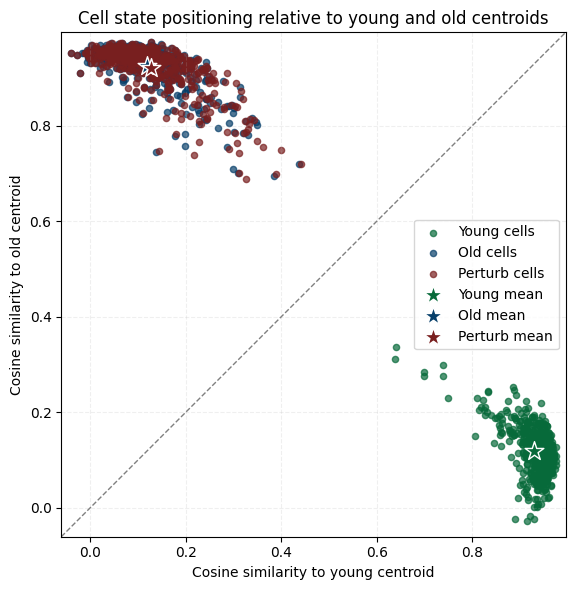

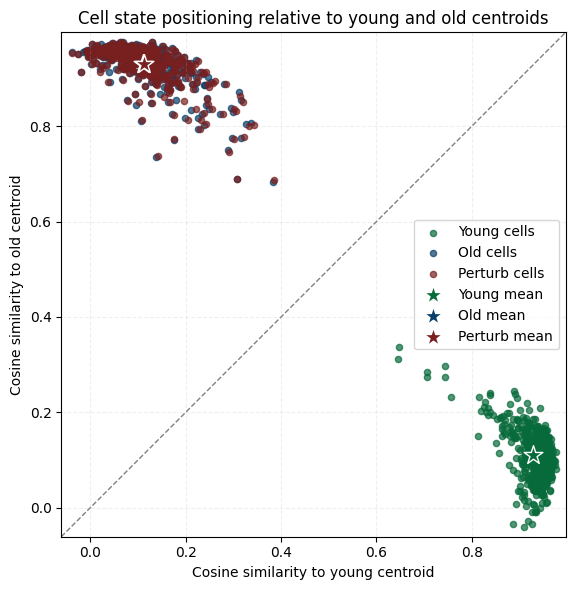

In [15]:
# all cell plot
plot_cosine_to_centroids_with_perturb(
    adata_ori=adata_ori,
    adata_perturb=adata_perturb_final,
    slice_young="Hippocampus_Y_2_1",
    slice_old="Hippocampus_O_2_1",
    target_celltype="OL-WM",
    exclude_celltype=False,
    # save_path=os.path.join(f"{out_fig_dir}/target_cell_cell_stat.pdf")
)

# niche-only
plot_cosine_to_centroids_with_perturb(
    adata_ori=adata_ori,
    adata_perturb=adata_perturb_final,
    slice_young="Hippocampus_Y_2_1",
    slice_old="Hippocampus_O_2_1",
    target_celltype="OL-WM",
    exclude_celltype=True,
    # save_path=os.path.join(f"{out_fig_dir}/niche_cell_cell_stat.pdf")
)

In [16]:
cosine_before_niche, cosine_after_niche = sim_ko_meg3_niche["cosine"]
euclid_before_niche, euclid_after_niche = sim_ko_meg3_niche["euclidean"]
emd_before_niche, emd_after_niche = sim_ko_meg3_niche["emd"]
mmd_before_niche, mmd_after_niche = sim_ko_meg3_niche["mmd"]

print("Niche cosine similarity: before KO = {:.4f}, after KO = {:.4f}".format(cosine_before_niche, cosine_after_niche))
print("Niche Euclidean distance: before KO = {:.4f}, after KO = {:.4f}".format(euclid_before_niche, euclid_after_niche))
print("Niche Wasserstein distance (EMD): before KO = {:.4f}, after KO = {:.4f}".format(emd_before_niche, emd_after_niche))
print("Niche MMD: before KO = {:.4f}, after KO = {:.4f}".format(mmd_before_niche, mmd_after_niche))

Niche cosine similarity: before KO = 0.1120, after KO = 0.1143
Niche Euclidean distance: before KO = 13.0246, after KO = 12.9961
Niche Wasserstein distance (EMD): before KO = 0.3707, after KO = 0.3694
Niche MMD: before KO = 0.0050, after KO = 0.0050
